In [5]:
import pandas as pd

In [7]:
df = pd.read_csv("data/data.csv")
df = df.sample(n=5000, random_state=42).reset_index(drop=True)
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.910,1977,0.500,['Idris Muhammad'],0.894,273067,0.5210,0,0KdzyvsBqX1HV3uLxGm2JV,0.772,4,0.068,-7.048,1,Camby Bolongo,34,1977,0.0847,126.805
1,0.583,1976,0.930,['Stan Getz'],0.585,182200,0.2720,0,1f4eO5waC6glPLXUhYKLm2,0.115,11,0.128,-16.693,0,Just One of Those Things,26,1976,0.0802,90.104
2,0.647,1994,0.157,"['Warren G', 'The Twinz']",0.878,179933,0.5200,1,1X07ZfF5KQt8dyJ5kAkVAQ,0.000,7,0.173,-12.609,1,Recognize,38,1994-06-07,0.4030,90.744
3,0.196,1957,0.937,['Red Garland Quintet'],0.463,925947,0.2870,0,5wmMDeM4qvLfwqLa2cvoks,0.837,0,0.112,-11.758,0,Soul Junction,13,1957,0.0363,186.764
4,0.422,1921,0.995,['Ignacio Corsini'],0.648,154240,0.0995,0,0SK1upzAP6NvIgF0uGh6z2,0.846,11,0.112,-22.429,1,Flor Marchita - Remasterizado,0,1921-03-20,0.1050,71.978


# Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "valence", "danceability", "energy", "tempo",
    "acousticness", "liveness", "speechiness", "instrumentalness"
]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_features]), columns=numerical_features)
df_scaled

,valence,danceability,energy,tempo,acousticness,liveness,speechiness,instrumentalness
0,1.473178,2.032267,0.142150,0.310507,-0.005840,-0.783298,-0.107375,1.916073
1,0.226049,0.276101,-0.771789,-0.886487,1.126217,-0.446557,-0.133457,-0.171477
2,0.470135,1.941333,0.138480,-0.865614,-0.908852,-0.194001,1.737477,-0.536877
3,-1.249911,-0.417272,-0.716732,2.266056,1.144646,-0.536354,-0.387900,2.122604
4,-0.387981,0.634154,-1.404939,-1.477663,1.297342,-0.536354,0.010283,2.151200
...,...,...,...,...,...,...,...,...
4995,0.336651,-0.019435,0.810170,0.374302,-0.837769,-0.598090,-0.353124,-0.536877
4996,1.507503,1.009258,1.357065,-0.824128,-1.106567,0.434583,-0.270821,-0.536877
4997,-0.681647,-1.826752,-0.599278,-2.003804,0.999848,0.114678,-0.387900,-0.536835
4998,-0.906665,-0.815109,-1.495966,-0.516212,1.284178,-0.592478,-0.412243,-0.287769


# Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df_scaled, test_size=0.2, random_state=42)

# Elbow Method plot
to Find optimal K

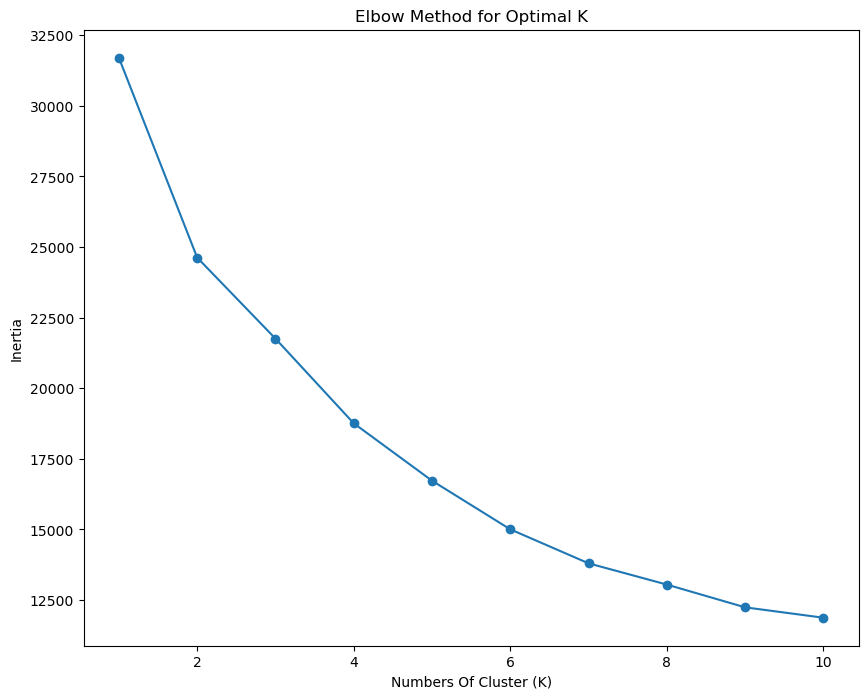

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values =range(1,11)

for k in k_values:
    Kmeans = KMeans(n_clusters=k, random_state=42)
    Kmeans.fit(train_data)
    inertia.append(Kmeans.inertia_)

plt.figure(figsize=(10,8))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Numbers Of Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


# Applying Kmeans

In [16]:
optimal_k = 5
Kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = Kmeans.fit_predict(df_scaled)


In [18]:
df['Cluster'].value_counts()

Cluster
1    1371
0    1369
4    1104
2     948
3     208
Name: count, dtype: int64

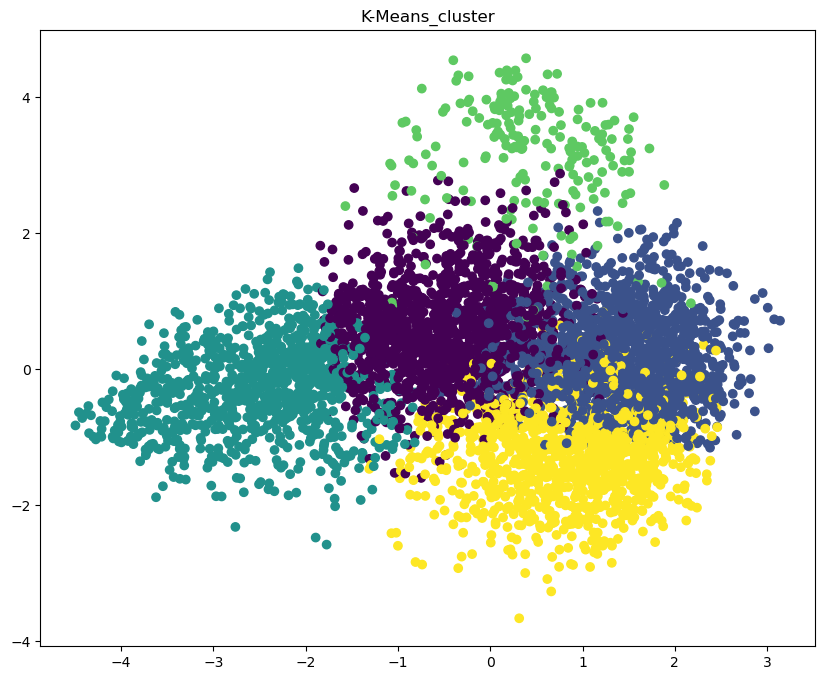

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,8))
plt.scatter(pca_result[:,0], pca_result[:,1], c=df['Cluster'], cmap='viridis')
plt.title("K-Means_cluster")
plt.show()

# Recommedation system with Kmeans

In [27]:
print(df.columns)

Index(['valence', 'year', 'acousticness', 'artists', 'danceability',
       'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
       'speechiness', 'tempo', 'Cluster'],
      dtype='object')


In [28]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_song(song_name, df, numerical_features, num_recommendations=5):
    
    # Get cluster of the input song
    song_cluster = df[df['name'] == song_name]['Cluster'].values[0]
    
    # Filter songs in same cluster
    same_cluster_songs = df[df['Cluster'] == song_cluster].reset_index(drop=True)
    
    # Get index of the song in this filtered dataframe
    song_index = same_cluster_songs[same_cluster_songs['name'] == song_name].index[0]
    
    # Get features
    cluster_features = same_cluster_songs[numerical_features]
    
    # Compute similarity
    similarity = cosine_similarity(cluster_features, cluster_features)
    
    # Get top recommendations
    similar_songs = np.argsort(similarity[song_index])[-(num_recommendations + 1):-1][::-1]
    
    recommendations = same_cluster_songs.iloc[similar_songs][['name', 'year', 'artists']]
    
    return recommendations




In [29]:
# Example usage
input_song = "Camby Bolongo"
recommend_songs = recommend_song(input_song, df, numerical_features, num_recommendations=5)

print(recommend_songs)

                                          name  year                 artists
954                          Bitch to the Boys  1982            ['Shakatak']
835   Chella llà - Instrument and base Version  1942  ['Orchestra Studio 7']
1342                            Danse Fambeaux  1968            ['Dr. John']
867       Aragon - From The "Coffy" Soundtrack  1973           ['Roy Ayers']
167                                 Into Black  2011              ['Blouse']


In [33]:
# Example usage 2
input_song = 'Soul Junction'
recommend_songs = recommend_song(input_song, df, numerical_features, num_recommendations=5)

print(f"songs similar to '{input_song}':")
recommend_songs

songs similar to 'Soul Junction':


,name,year,artists
97,Ahmad's Blues,1951,['Ahmad Jamal']
32,Laura,1945,['Erroll Garner']
616,"Kinderszenen, Op. 15: No. 8, Am Kamin",1962,"['Robert Schumann', 'Vladimir Horowitz']"
215,"Concerto For 2 Mandolins, Strings And Continuo...",1985,"['Antonio Vivaldi', 'Angel Romero', 'Pepe Rome..."
862,Pictures at an Exhibition: VI. Samuel Goldenbe...,1950,"['Modest Mussorgsky', 'Leonard Bernstein', 'Ne..."


In [34]:
df.to_csv("clustered_df.csv")